In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/MicroMirror"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_13652\2400657434.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


In [9]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
datadir = r'C:\Users\TengMa\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus'
positionname = 'sindy_perseus_S_FRF_IC0.mat'
velocityname = 'sindy_perseus_S_vel_FRF_IC0.mat'
datafile = "%s/%s"%(datadir, positionname)
P = "%s/%s"%(datadir, 'sindy_perseus_I_FRF_IC0.mat')
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
with h5py.File(datafile, 'r') as file:
    data = np.array(file['S'])
with h5py.File(P, 'r') as file:
    p = np.array(file['I'])


In [10]:
timestamp = 99999
timeeffect = 99999
Modes = 3
Modeshape = loadmat(POM)["POM"]
node = 7178
POM_1 = Modeshape[node,:3]
print(POM_1)

[ 0.04229482  0.02260849 -0.01295628]


0.18384196289438473 1.5


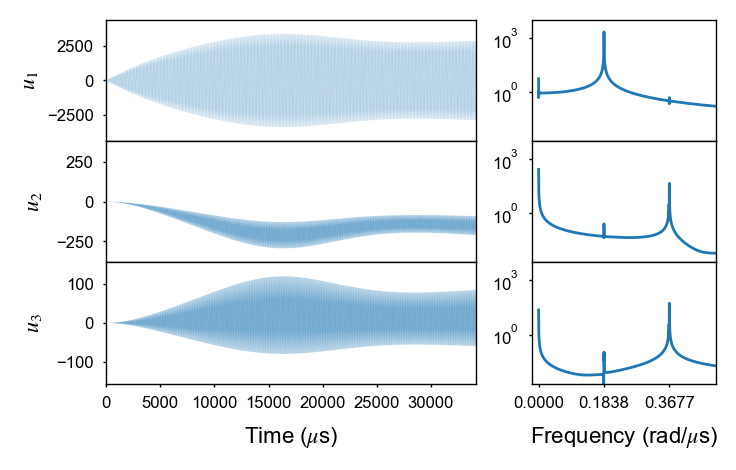

In [83]:
num = 18
start = num*timestamp+1
end = (num+1)*timestamp
F_omega1 = p[1,start]
F_amplitude = p[2,start]
print(F_omega1, F_amplitude)

t = p[0,start:start+timeeffect]
F = np.cos(F_omega1*t)
ylabels = ['$u_1$','$u_2$','$u_3$','$u_4']
ylabels_pad = [2.5,4.5,4.5,0]
fig, axes = plt.subplots(Modes,2,figsize =  (10/2.54,6/2.54),  gridspec_kw={'width_ratios': [2, 1]},dpi = 200)
plt.subplots_adjust(hspace = 0)
for mode in range(Modes):
    ax = axes[mode][0]
    if mode != Modes-1:
        axes[mode][0].set_xticks([])
        axes[mode][1].set_xticks([])
    else:
        axes[mode][1].set_xticks([0,F_omega1,2*F_omega1,3*F_omega1])
        axes[mode][0].set_xlabel("Time ($\mu$s)",labelpad = 5)
        axes[mode][1].set_xlabel("Frequency (rad/$\mu$s)",labelpad = 5)
    y = data[mode,start:start+timeeffect]
    ax.set_ylabel(ylabels[mode], labelpad = ylabels_pad[mode])
    ax.plot(t,y,lw = 0.02)
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_xlim(0,t[-1])
    ax.set_ylim(-np.max(np.abs(y))*1.3,np.max(np.abs(y))*1.3)
    ax = axes[mode][1]
    N = len(y)
    yf = fft(y)
    xf = fftfreq(N, (t[-1]-t[0])/timestamp)[:N//2]
    ax.plot(xf*2*np.pi, 2.0/N * np.abs(yf[0:N//2]), lw = 1)
    ax.set_xlim(-0.02,0.5)
    
    # ax.set_xticklabels(['$0$',r'$\hat{\omega}$',r'$2\hat{\omega}$',r'$3\hat{\omega}$'])
    ax.set_yscale('log')
    ax.tick_params(direction='out',width = 0.5,length = 1)
    ax.set_ylim(0.002,10000)
# orbit = np.sum(data[:Modes,start+timeeffect-1000:start+timeeffect].T * POM_1, axis = 1)
# Train_FRF = np.degrees(np.arcsin((np.max(orbit) - np.min(orbit))/2/1000))
# Train_FREQ = F_omega1
# print(Train_FREQ, Train_FRF)
plt.savefig("%s/OriginPOD.svg"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [54]:
import importlib
import sys
sys.path.append("../")
import EvLOWN
importlib.reload(EvLOWN)  # 重新载入
library = [
    lambda x:x[0],
    lambda x:x[0]*x[0],
    lambda x:x[0]*x[0]*x[0],
    lambda x:x[1],
    lambda x:x[1]*x[1],
    lambda x:x[1]*x[1]*x[1],
    lambda x:x[2],
    lambda x:x[2]*x[2],
    lambda x:x[2]*x[2]*x[2],
    lambda x:x[3],
    lambda x:x[3]*x[3],
    lambda x:x[3]*x[3]*x[3],
    lambda x:x[4],
    lambda x:x[4]*x[4],
    lambda x:x[4]*x[4]*x[4],
    lambda x:x[5],
    lambda x:x[5]*x[5],
    lambda x:x[5]*x[5]*x[5],

]
library_name = [
    lambda x:x[0],
    lambda x:x[0]+x[0],
    lambda x:x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[0],
    lambda x:x[1],
    lambda x:x[1]+x[1],
    lambda x:x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1],
    lambda x:x[0]+x[0]+x[1],
    lambda x:x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1]+x[1],
]
dim = 3
model = EvLOWN.WeakNOForce(dim,library,library_name)

In [57]:
print(Modes)
Xis = np.zeros([len(library)+1,Modes])
# fig, axes = plt.subplots(Modes,2,figsize = (4,Modes*0.5),dpi = 200)
# plt.subplots_adjust(hspace = 0, wspace = 0.15)
displacement = data[:Modes,start:start+timeeffect]
velocity = np.zeros([Modes,timeeffect])
for mode in range(Modes):
    velocity[mode] = np.gradient(data[mode,start:start+timeeffect],t)
# velocity = np.gradient(data[:Modes,start:start+timeeffect],t,axis = 0)
model.Get_frequency(displacement.T,velocity.T,t[:])
print(model.frequencys)
model.frequencys[1] = model.frequencys[0]
model.frequencys[2] = model.frequencys[0]
model.Get_Evolution(order = [0,1,2,3])
model.Library_rebuild(F[:])
T_period = 2*np.pi/model.frequencys[0]
num_period = int((t[-1] - t[0]) // T_period)
t_periods = np.linspace(0,t[-1], num_period+1)
Fs = timeeffect/(t[-1]-t[0])
print(Fs)

3
[0.18367418 0.         0.36748869]
2.92713582850767


In [58]:
orders = [[1,2],[0,3,4],[0,3,4]]
model.optimize(orders = orders, startcycle = 10, endcycle=10,sparse_threshold=0.3, stop_tolerance=0.05)


start:4.87320
Round 0, step: 0.31384, now: 0.68616, selected: 18
Round 1, step: 0.27615, now: 0.41000, selected: 3
Round 2, step: 0.08793, now: 0.32207, selected: 0
Round 3, step: 0.30933, now: 0.01275, selected: 2
start:244.93697
Round 0, step: 0.90536, now: 0.09464, selected: 4
Round 1, step: 0.08931, now: 0.00533, selected: 1
start:224.95360
Round 0, step: 0.06468, now: 0.93532, selected: 1
Round 1, step: 0.93043, now: 0.00490, selected: 4


In [59]:
print(model.Xi)  

[[ 9.62488110e-05  0.00000000e+00 -1.17987405e-11  1.86470422e-04
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.61352482e-01]
 [ 0.00000000e+00 -1.10292147e-07  0.00000000e+00  0.00000000e+00
   3.91240237e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -9.12711093e-07  0.00000000e+00  0.00000000e+00
   2.39225742e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]]


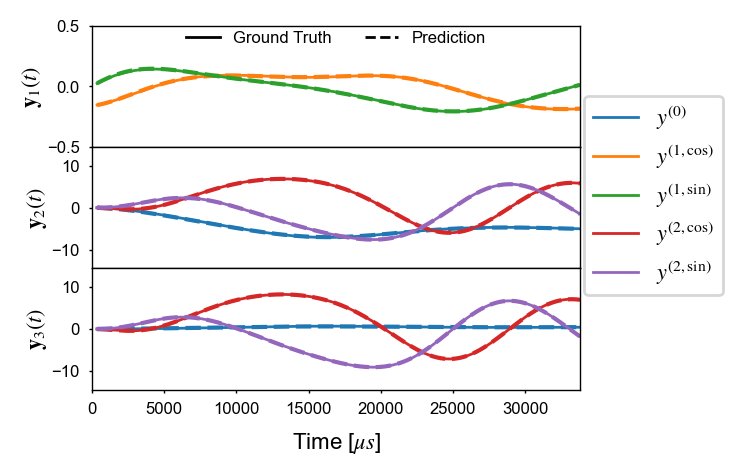

In [85]:
stp = 10
enp = 10
Omegaidxs = [0,6,12,18]
Xis = np.zeros([len(library)+1, Modes])
fig, axes = plt.subplots(Modes,1,figsize = (8/2.54,6/2.54),dpi = 200)
plt.subplots_adjust(hspace = 0)
ylims = [(-0.5,0.5),(-14.5,14.5),(-14.5,14.5)]
legends = ['$y^{(0)}$','$y^{(1,\cos)}$','$y^{(1,\sin)}$','$y^{(2,\cos)}$','$y^{(2,\sin)}$']
for d in range(Modes):
    Xi = model.Xi[d]
    Xis[:,d] = Xi
    Xis[Omegaidxs[d],d] += model.frequencys[0]**2
    Xis[-1,d] = Xis[-1,d]/F_amplitude
    # for d in range(3):
    #     ax = axes[d]
    ax = axes[d]
    ax.set_xlabel('Time [$\mu s$]',labelpad = 5)
    if d!=2:
        ax.set_xticks([])
        ax.set_xlabel("")
    ax.set_xlim(0,t_periods[-1-enp])
    ax.set_ylim(ylims[d])
    ax.set_ylabel(r'$\mathbf{y}_%d(t)$'%(d+1))
    ax.tick_params(direction='out',width = 0.5,length = 1)
    if d == 0:
        for i in range(5):
            ax.plot([-1,-1], [-1,-1] ,color = colors[i],lw = 1, label = legends[i])
        ax.legend(loc = 'center',bbox_to_anchor = (1.15,-0.4))
    if d == 1:
        ax.plot([-1,-1], [-1,-1] ,color = 'black',lw = 1, label = 'Ground Truth')
        ax.plot([-1,-1], [-1,-1] ,color = 'black',lw = 1, ls = '--', label = 'Prediction')
        ax.legend(ncol = 2,loc = 'center',bbox_to_anchor = (0.5,1.9), frameon = False,fontsize = 6)
    for i in orders[d]:
        ax.plot(t_periods[stp:-enp-1],model.dot[d][stp:-enp,i],color = colors[i],lw = 1)
        ax.plot(t_periods[stp:-enp-1],np.sum(model.Phi[d][stp:-enp,i,:]*Xi, axis = 1),color = colors[i],ls = '--',lw = 1.5)

plt.savefig("../../Elements/MicroMirror/Slowvarying_%d.svg"%num,dpi = 300,transparent = True,bbox_inches="tight")

In [61]:
Xis

array([[ 3.38324550e-02,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -1.10292147e-07, -9.12711093e-07],
       [-1.17987405e-11,  0.00000000e+00,  0.00000000e+00],
       [ 1.86470422e-04,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  3.91240237e-05,  2.39225742e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  3.37362062e-02,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  3.37362062e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00

In [62]:
import util
importlib.reload(util)  # 重新载入
library_matlab = [
    'u1','u1^2','u1^3','v1','v1^2','v1^3',
    'u2','u2^2','u2^3','v2','v2^2','v2^3',
    'u3','u3^2','u3^3','v3','v3^2','v3^3',
    'A*c'
]
util.generate_beam_from_library(
    func_name = "Mirror_POM3_%d"%num,
    out_path = "../Matcont_solver/models/MicroMirror/Mirror_POM3_%d.m"%num,
    n_dof = Modes,
    library = library_matlab,
    coef = -1*np.array(Xis),
    tol = 1e-14
    
)
util.append_coef_only_csv(
    csv_path = "Mirror_coef.csv",
    library = library_matlab,
    coef = -1*np.array(Xis),
    eq_names = ['v1','v2','v3'],
    idx = num,
    tol = 1e-14
)

PermissionError: [Errno 13] Permission denied: 'Mirror_coef.csv'

In [63]:
def ROM_Mirror(x,t):
    dxdt = np.zeros(len(x))
    for d in range(Modes):
        dxdt[d*2] = x[d*2+1]
        for i in range(len(library)):
            dxdt[d*2+1] -= library[i](x)*Xis[i,d]
        dxdt[d*2+1] -= np.cos(F_omega1*t)*Xis[-1,d]*F_amplitude
    return dxdt


x0 = np.zeros(Modes*2)
x = odeint(ROM_Mirror, x0, t)

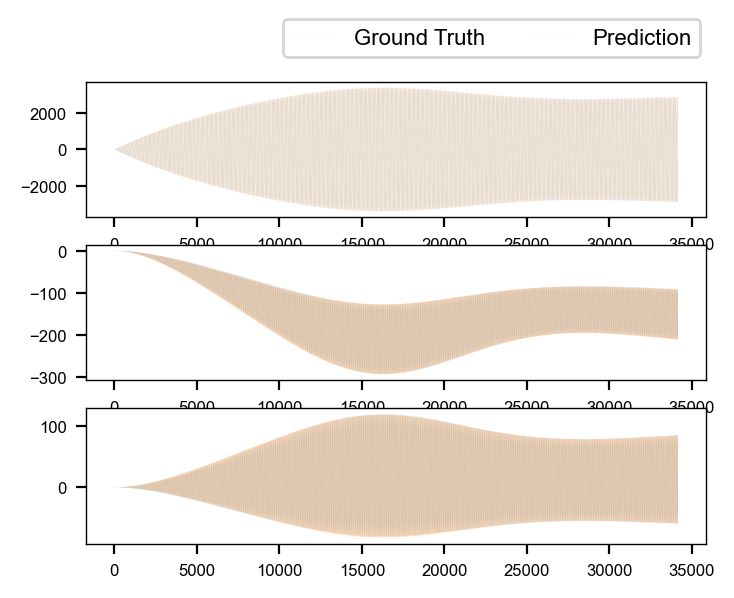

In [64]:
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for i in range(Modes):
    ax = axes[i]
    ax.plot(t, data[i, start:start+timeeffect], lw = 0.01,label = 'Ground Truth')
    ax.plot(t, x[:,i*2],lw = 0.02, ls = '--', label = 'Prediction')
    # ax.set_xlim(0,1000)
    if i == 0:
        ax.legend(ncol = 2, bbox_to_anchor = (0.3,1.1))

In [65]:
def ROM_Mirror(x,t):
    dxdt = np.zeros(len(x))
    for d in range(3):
        dxdt[d*2] = x[d*2+1]
        for i in range(len(library)):
            dxdt[d*2+1] -= library[i](x)*Xis[i,d]
        dxdt[d*2+1] -= np.cos(F_omega1*t)*Xis[-1,d]
    return dxdt

t_pred = np.linspace(0,timeeffect,timeeffect*2)
x0 = [0,0,0,0,0,0]
x = odeint(ROM_Mirror, x0, t_pred)


6.362713374568607


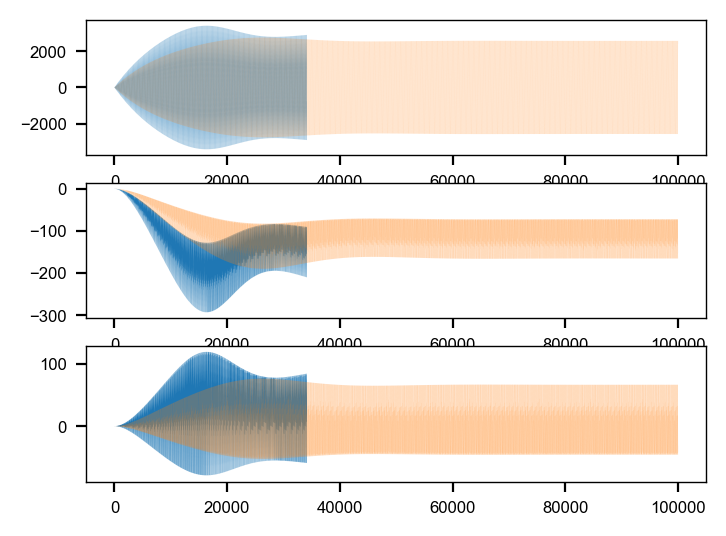

In [66]:
orbit = np.sum(x[2*timeeffect-5000:2*timeeffect,[0,2,4]] * Modeshape[node,:3], axis = 1)
Train_FRF = np.max(np.degrees(np.arcsin(np.abs(orbit)/1010)))
print(Train_FRF)
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for i in range(Modes):
    ax = axes[i]
    ax.plot(t, data[i, start:start+timeeffect], lw = 0.02)
    ax.plot(t_pred, x[:,i*2],lw = 0.01, ls = '--')
    # ax.set_xlim(0,t[-1])
    # ax.set_xlim(32000,33000)

In [52]:
# MATCONT 求解ROM
import os
import numpy as np
import matlab.engine
from tqdm import tqdm

PROJECT = r"../matcont_solver/"   # 改成你的路径
RESULTS = os.path.join(PROJECT, "results")
os.makedirs(RESULTS, exist_ok=True)

models = ["Mirror_POM3_7"]  # 你可以放多个模型函数名
As = [0.5,0.75,1.0,1.25,1.50]

omega0 = 0.1839
Qvalue = 1000.0
X0 = [0,0,0,0,0,0,1,0]

eng = matlab.engine.start_matlab()
eng.cd(PROJECT, nargout=0)
eng.addpath(eng.genpath(PROJECT), nargout=0)
print(eng.pwd())
print(eng.which('run_frf_mirror'))

for i in range(1,2):
    model = 'Mirror_POM3_%d'%i
    for A in tqdm(As, desc=f"A sweep ({model})", position=1, leave=False):
        eng.eval(f"global Global_A; Global_A = {A};", nargout=0)
        
        out = eng.run_frf_mirror(
            model,
            float(omega0*1.1),
            matlab.double(X0),   # MATLAB 内部会 X0(:)
            float(Qvalue),
            nargout=1
        )
        # print(model, A, "is_empty:", eng.isempty(out))
        eng.workspace["xlcc"] = out
        savename = os.path.join(RESULTS, f"{model}_A_{A:.5f}.mat")
        eng.save(savename, "xlcc", nargout=0)

eng.quit()

C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver
C:\Users\TengMa\OneDrive\文章\9. MEMS_FEM_EvLOWN\Notebook\Matcont_solver\run_frf_mirror.m



A sweep (Mirror_POM3_1): 100%|██████████████████████████████████████████████████████████| 5/5 [15:54<00:00, 206.13s/it]
                                                                                                                       

In [415]:
0.1839*0.95

0.174705

In [11]:
def xlcc2frf(xlcc,Modeshape, node):
    d1, d2 = np.shape(xlcc)
    num = 3
    orbit_len = (d1-2-2-num*2)//(num*2+2)
    frfs = np.zeros(d2)
    for j in range(d2):
        orbits = np.zeros([orbit_len,num])
        for i in range(num):
            orbits[:,i] = xlcc[i*2:-((num+1)*2)-2+i*2:(num+1)*2, j]
        orbit_e2 = np.sum(orbits * Modeshape[node-1,:3], axis = 1)
        orbit_e3 = np.sum(orbits * Modeshape[node,:3], axis = 1)
        frfs_orbit =  2*np.degrees(np.arctan2(np.sqrt(orbit_e2**2 + orbit_e3**2)/2,950))
        frfs[j] = np.max(frfs_orbit)
    return xlcc[-1,:], frfs

In [1]:
import pandas as pd
import scipy
num = 1
Omegas_FOMs = []
response_FOMs = []
Omegas_ROMs = []
node = 7178
POM_1 = Modeshape[node,:3]
response_ROMs = []
PROJECT = r"../matcont_solver/"   # 改成你的路径
betas = [1.0,1.5,2.0,2.5,3.0]
trainset = pd.read_csv("../../Validation/Micromirror2/trainset.csv")
Train_FREQ = trainset['omegas'][num]
Train_FRF = trainset['As'][num]
model_mirror = 'Mirror_POM3_%d'%num
for i in range(len(betas)):
    file = "../../Validation/Micromirror2/beta%.1f-1.csv"%betas[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOMs.append(data_FOM[0])
    response_FOMs.append(data_FOM[1])
    # if i >=0:
    #     y = scipy.io.loadmat('../../Validation/Micromirror2/matcont_origin_norm_3_%.2f_%d.mat'%(betas[i]/2,num))
    #     y = y['xlcc']
    #     freq, frf = xlcc2frf(y, Modeshape, 4526)

    
    #     frf = frf*1000
    # else:
    y = scipy.io.loadmat('%s/results/%s_A_%.5f'%(PROJECT,model_mirror,betas[i]/2))
    y = y['xlcc']
# print(POM_1)
    freq, frf = xlcc2frf(y, Modeshape, 4526)
    Omegas_ROMs.append(freq[:-1])
    response_ROMs.append(frf[:-1])

NameError: name 'Modeshape' is not defined

In [ ]:
fig, ax = plt.subplots(figsize = (9/2.54, 6.5/2.54),dpi = 300)
cm_number = 8
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
length = 1000
l_idx = [0,51,56,61,65]
r_idx = [0,51,59,65,70]
for i in range(len(betas)):
    
    plt.plot(Omegas_FOMs[i], response_FOMs[i], color = colors[i+3],alpha = 0.5,lw = 1, ls = '-')
    plt.plot(Omegas_ROMs[i], response_ROMs[i], lw = 0.75,ls = '--', color = colors[i+3])
# plt.plot(Omegas_ROM, np.degrees(np.arcsin(response_ROM[0,:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    # if i<1:

    #     plt.plot(Omegas_ROM, np.degrees(np.arcsin(response_ROM[i,:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    # else:
    #     plt.plot(Omegas_ROM[:l_idx[i]], np.degrees(np.arcsin(response_ROM[i,:l_idx[i]]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    #     plt.plot(Omegas_ROM[r_idx[i]:], np.degrees(np.arcsin(response_ROM[i,r_idx[i]:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
# plt.plot(freq[:-5],frf[:-5])
ax.scatter([Train_FREQ],[Train_FRF], color = 'red', s = 4,zorder = 100,label = 'Training Point')
ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')
plt.legend(fontsize = 6)
# plt.scatter(Omegas_FOM, responses_FOM, s =9,marker = '*',label = 'FOM',zorder = 100)
ax.set_ylim(0,12.5)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlim(0.1832,0.1844)
ax.set_xlabel('Frequency $\Omega$ (Hz)')
ax.set_ylabel(r'$\theta$ (deg)')

cmap_discrete = mpl.colors.ListedColormap(colors[3:])
bounds = list(range(3, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [3.5, 4.5, 5.5, 6.5, 7.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = ['1.0$\mu$N','1.5$\mu$N','2.0$\mu$N','2.5$\mu$N','3.0$\mu$N']  
ax.tick_params(direction='out',width = 0.5,length = 1)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label(r"Forcing intensity $\beta$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)

In [436]:
len(response_ROMs[1])

62